# Model anatomy

**What you'll learn / who it's for (simulation *and* training).** The shared
``Dynamics`` contract behind every neuron and synapse — the state variables they
own, the ``update()`` step, the ``get_spike()`` output, and how a neuron receives
current. This contract is exactly what projections rely on, so it sets up the
keystone chapter that follows.

## One contract: `Dynamics`

``brainpy.state`` models form a small, deliberate hierarchy:

```text
brainstate.nn.Module
└── Dynamics            (anything that evolves in time)
    ├── Neuron          (a population that integrates current and emits spikes)
    └── Synapse         (temporal filtering of a spike train)
```

Every ``Dynamics`` honors the same four-part contract:

1. **Declare state** in ``__init__`` (e.g. membrane potential ``V``, conductance
   ``g``).
2. **Allocate it** via ``init_all_states`` (which calls each object's
   ``init_state``).
3. **Advance one step** with ``update(...)`` — called for you when you invoke the
   module.
4. **Expose outputs** — neurons add ``get_spike()``.

Because the contract is uniform, components compose: a ``Synapse`` filters spikes
into a current, and a ``Neuron`` integrates that current — and a *projection*
(next chapter) snaps the two together across populations.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Neurons: integrate current, emit spikes

A neuron population owns a membrane potential ``V`` (a state) and a set of unitful
parameters (``tau``, ``V_th``, ``V_reset``, ``V_rest``, ``R``). Calling the neuron
with an input current advances ``V`` one ``dt`` and, when ``V`` crosses threshold,
emits a spike and resets.

In [2]:
neuron = brainpy.state.LIFRef(
    100,
    V_rest=-65. * u.mV, V_th=-50. * u.mV, V_reset=-65. * u.mV,
    tau=10. * u.ms, tau_ref=2. * u.ms,
    V_initializer=braintools.init.Normal(-65., 2., unit=u.mV),
)
brainstate.nn.init_all_states(neuron)

print('state variable V:', neuron.V.value.shape, neuron.V.value.dtype)

state variable V: (100,) float32


### `get_spike()`: the spike output

A neuron's spike output is read with ``get_spike()``. During training it is a
*surrogate* — a smooth, differentiable stand-in for the hard threshold (see
:doc:`/concepts/differentiability`) — but its role in wiring is always the same: it
is the signal a projection transmits to downstream populations.

In [3]:
def step(t):
    with brainstate.environ.context(t=t):
        neuron(jnp.ones(100) * 30. * u.mA)   # drive every neuron
        return neuron.V.value, neuron.get_spike()

with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 100. * u.ms, brainstate.environ.get_dt())
    vs, spikes = brainstate.transform.for_loop(step, times)

print('voltage trace:', vs.shape)      # (time, neurons)
print('spike trace:  ', spikes.shape)  # (time, neurons)
print('total spikes: ', int(u.math.sum(spikes)))

voltage trace: (1000, 100)
spike trace:   (1000, 100)


total spikes:  1100


### How a neuron receives current

Synaptic input does not overwrite a neuron's drive — it **accumulates** into it.
Internally a neuron sums all current contributions delivered during a step before
integrating ``V``. From your side this means you simply *call the neuron* with any
direct input, and projections add their synaptic current on top:

```python
self.proj(pre_spikes)   # projection deposits synaptic current into `post`
self.post(external)     # neuron integrates synaptic + external current
```

That additive convention is what lets several projections target the same
population and have their effects sum — the basis of the **automatic merging** you
will see in the keystone.

## Synapses: temporal filtering of spikes

A synapse turns a discrete spike train into a continuous signal. The most common is
the **exponential** synapse: each arriving spike bumps a conductance ``g`` that then
decays.

$$\tau \frac{dg}{dt} = -g, \qquad g \leftarrow g + 1 \text{ on each spike.}$$

That ``g ← g + 1`` increment is *identity-agnostic* — it does not matter which
presynaptic neuron fired — and that single fact is what makes the AlignPost
reduction in the next chapter exact. Keep it in mind.

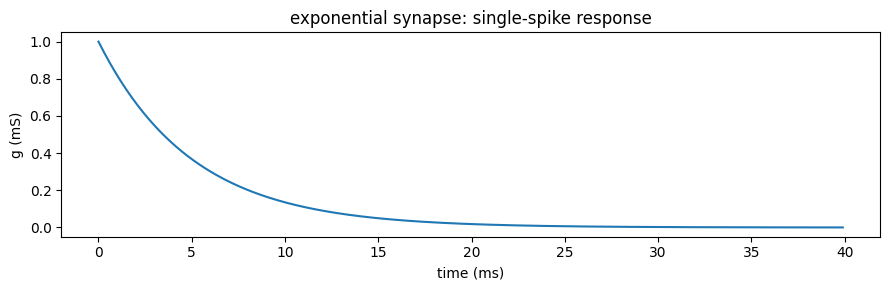

In [4]:
syn = brainpy.state.Expon(1, tau=5. * u.ms,
                          g_initializer=braintools.init.Constant(0. * u.mS))
brainstate.nn.init_all_states(syn)

def syn_step(t):
    with brainstate.environ.context(t=t):
        # a single spike at t = 0, nothing afterwards
        spike = u.math.where(t == 0. * u.ms, 1.0 * u.mS, 0.0 * u.mS)
        return syn(spike)

with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 40. * u.ms, brainstate.environ.get_dt())
    g = brainstate.transform.for_loop(syn_step, times)

plt.figure(figsize=(9, 3))
plt.plot(times.to_decimal(u.ms), g.to_decimal(u.mS).squeeze())
plt.xlabel('time (ms)'); plt.ylabel('g (mS)'); plt.title('exponential synapse: single-spike response')
plt.tight_layout(); plt.show()

The family extends well beyond the single exponential — ``DualExpon`` and ``Alpha``
add a rise time; ``AMPA``, ``GABAa``, and ``BioNMDA`` model receptor kinetics, some
of them *nonlinear* in the conductance. That linear-vs-nonlinear distinction decides
which projection alignment applies, the central question of the next chapter. (Note
the names: it is ``GABAa`` and ``BioNMDA``, not ``GABA``/``NMDA``.)

## Outputs: from conductance to current

A synapse produces a conductance; an **output** converts it into the current the
postsynaptic neuron actually feels. The choice encodes the biophysics:

- **CUBA** (current-based): $I = g$. Simple, fast, voltage-independent.
- **COBA** (conductance-based): $I = g\,(E - V)$, with a reversal potential ``E``.
  Self-limiting and biologically realistic — excitatory with ``E = 0 mV``,
  inhibitory with ``E = -80 mV``.
- **MgBlock** (NMDA): COBA plus a voltage-dependent magnesium block.

You do not wire an output by hand — it is one of the four components a *projection*
assembles, which is precisely where we go next.

In [5]:
cuba = brainpy.state.CUBA()
exc = brainpy.state.COBA(E=0. * u.mV)
inh = brainpy.state.COBA(E=-80. * u.mV)
print(cuba, exc, inh)

CUBA(
  scale=Unit("V")
) COBA(
  E=Quantity(0., "mV")
) COBA(
  E=Quantity(-80., "mV")
)


## Recap

- Neurons and synapses share one **``Dynamics``** contract: declare state →
  allocate → ``update()`` → expose outputs.
- A **neuron** integrates current and emits spikes via ``get_spike()``; synaptic
  input **accumulates** additively into its drive.
- A **synapse** filters spikes into a conductance; the exponential synapse's
  ``g ← g + 1`` increment is *identity-agnostic*.
- An **output** (CUBA / COBA / MgBlock) turns conductance into current.

These four pieces — communication, synapse, output, postsynaptic population — are
exactly what a projection composes.

## See also

- :doc:`/concepts/alignpre-alignpost` — **the keystone**: how projections wire
  these pieces across populations, memory-efficiently and exactly.
- :doc:`/concepts/state-paradigm` — the state and ``transform`` machinery used
  above.
- :doc:`/concepts/physical-units` — the units every parameter carries.
- :doc:`/apis/index` — the full catalog of neuron, synapse, and output models.